In [49]:
!pip install tensorflow matplotlib pandas
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2, ResNet50, EfficientNetB0
import gc

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))


TensorFlow Version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [50]:

# =====================================================
# LOAD CIFAR-10 DATASET
# =====================================================

(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Use subset to reduce memory usage
X_train = X_train[:10000]
y_train = y_train[:10000]

X_test = X_test[:2000]
y_test = y_test[:2000]

# Normalize
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)


Training Shape: (10000, 32, 32, 3)
Testing Shape: (2000, 32, 32, 3)


In [51]:

# =====================================================
# CREATE DATASET PIPELINE
# =====================================================

IMG_SIZE = 96
BATCH_SIZE = 32

def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    return image, label

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds = train_ds.shuffle(1000)
train_ds = train_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.batch(BATCH_SIZE)
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_ds = test_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

results = {}


In [52]:
# =====================================================
# CUSTOM CNN
# =====================================================

print("\nTraining CNN...")

cnn = models.Sequential([
    layers.Input(shape=(96,96,3)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(10, activation='softmax')
])

cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn.fit(
    train_ds,
    epochs=5,
    validation_data=test_ds,
    verbose=1
)

loss, acc = cnn.evaluate(test_ds, verbose=0)
results["CNN"] = acc * 100

tf.keras.backend.clear_session()
gc.collect()



Training CNN...
Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 29ms/step - accuracy: 0.2875 - loss: 1.9331 - val_accuracy: 0.4155 - val_loss: 1.6073
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.4270 - loss: 1.5803 - val_accuracy: 0.4915 - val_loss: 1.4314
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.4892 - loss: 1.4055 - val_accuracy: 0.5060 - val_loss: 1.3462
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.5391 - loss: 1.2796 - val_accuracy: 0.5430 - val_loss: 1.3141
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.5771 - loss: 1.1667 - val_accuracy: 0.5375 - val_loss: 1.3260


0

In [62]:
# =====================================================
# FUNCTION FOR TRANSFER LEARNING MODELS
# =====================================================

def train_pretrained(base_model_fn, model_name):

    print(f"\nTraining {model_name}...")

    base_model = base_model_fn(
        weights='imagenet',
        include_top=False,
        input_shape=(96,96,3)
    )

    base_model.trainable = False

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    model.fit(
        train_ds,
        epochs=3,
        validation_data=test_ds,
        verbose=1
    )

    loss, acc = model.evaluate(test_ds, verbose=0)

    results[model_name] = acc * 100

    tf.keras.backend.clear_session()
    gc.collect()


In [54]:
# =====================================================
# MOBILE NET V2
# =====================================================

train_pretrained(
    MobileNetV2,
    "MobileNetV2"
)



Training MobileNetV2...
Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 25s 53ms/step - accuracy: 0.6371 - loss: 1.0685 - val_accuracy: 0.7440 - val_loss: 0.7413
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7424 - loss: 0.7373 - val_accuracy: 0.7660 - val_loss: 0.6641
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.7781 - loss: 0.6337 - val_accuracy: 0.7770 - val_loss: 0.6387


In [55]:

# =====================================================
# RESNET50
# =====================================================

train_pretrained(
    ResNet50,
    "ResNet50"
)



Training ResNet50...
Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 37s 84ms/step - accuracy: 0.1372 - loss: 2.2852 - val_accuracy: 0.1705 - val_loss: 2.2264
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 28ms/step - accuracy: 0.1818 - loss: 2.1866 - val_accuracy: 0.2045 - val_loss: 2.1328
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.2161 - loss: 2.0994 - val_accuracy: 0.2380 - val_loss: 2.0494


In [56]:

# =====================================================
# EFFICIENTNET B0
# =====================================================

train_pretrained(
    EfficientNetB0,
    "EfficientNetB0"
)



Training EfficientNetB0...
Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 50s 90ms/step - accuracy: 0.0981 - loss: 2.3067 - val_accuracy: 0.0995 - val_loss: 2.3025
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.1004 - loss: 2.3025 - val_accuracy: 0.0975 - val_loss: 2.3023
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.0997 - loss: 2.3024 - val_accuracy: 0.0975 - val_loss: 2.3022


In [59]:

# =====================================================
# RESULTS
# =====================================================

print("\n============================")
print("MODEL ACCURACY COMPARISON")
print("============================")

for model, accuracy in results.items():
    print(f"{model:15s} : {accuracy:.2f}%")



MODEL ACCURACY COMPARISON
CNN             : 53.75%
MobileNetV2     : 77.70%
ResNet50        : 23.80%
EfficientNetB0  : 9.75%


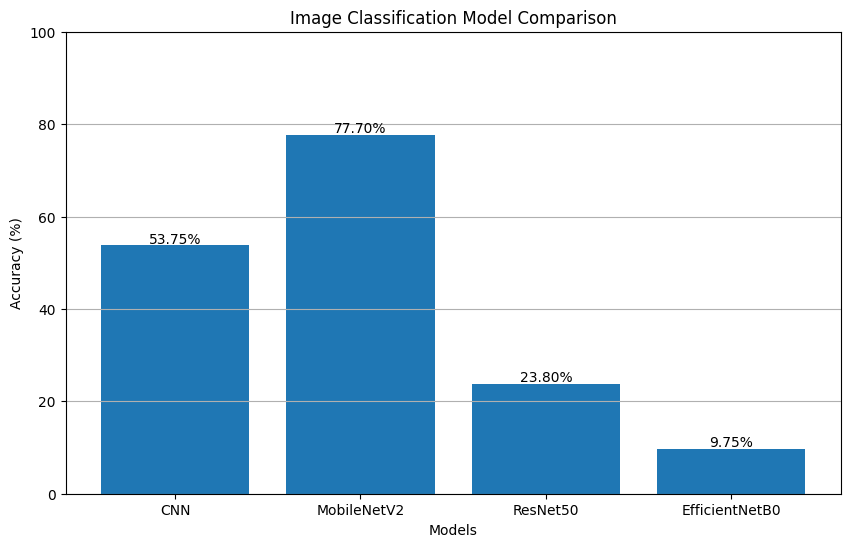

In [57]:
# =====================================================
# BAR GRAPH
# =====================================================

model_names = list(results.keys())
accuracies = list(results.values())

plt.figure(figsize=(10,6))

bars = plt.bar(model_names, accuracies)

plt.title("Image Classification Model Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy (%)")

for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y + 0.5,
        f"{y:.2f}%",
        ha='center'
    )

plt.ylim(0,100)
plt.grid(axis='y')

plt.show()


In [58]:
# =====================================================
# BEST MODEL
# =====================================================

best_model = max(results, key=results.get)

print("\nBest Model:", best_model)
print("Best Accuracy:", round(results[best_model],2), "%")



Best Model: MobileNetV2
Best Accuracy: 77.7 %


In [63]:
!pip install transformers datasets torch torchvision pillow matplotlib scikit-learn

In [64]:
from datasets import load_dataset

dataset = load_dataset("dpdl-benchmark/plant_village")

print(dataset)
print(dataset["train"][0])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/368 [00:00<?, ?B/s]

data/train-00000-of-00013.parquet:   0%|          | 0.00/485M [00:00<?, ?B/s]

data/train-00001-of-00013.parquet:   0%|          | 0.00/484M [00:00<?, ?B/s]

data/train-00002-of-00013.parquet:   0%|          | 0.00/483M [00:00<?, ?B/s]

...

data/train-00010-of-00013.parquet:   0%|          | 0.00/482M [00:00<?, ?B/s]

data/train-00011-of-00013.parquet:   0%|          | 0.00/485M [00:00<?, ?B/s]

data/train-00012-of-00013.parquet:   0%|          | 0.00/484M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/54303 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'image/filename', 'label'],
        num_rows: 54303
    })
})
{'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=256x256 at 0x789F9C7A5B50>, 'image/filename': "b'image (785).JPG'", 'label': 35}


TensorFlow Version: 2.20.0
Dataset Location: /root/.keras/datasets/flower_photos/flower_photos
Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.
Classes: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


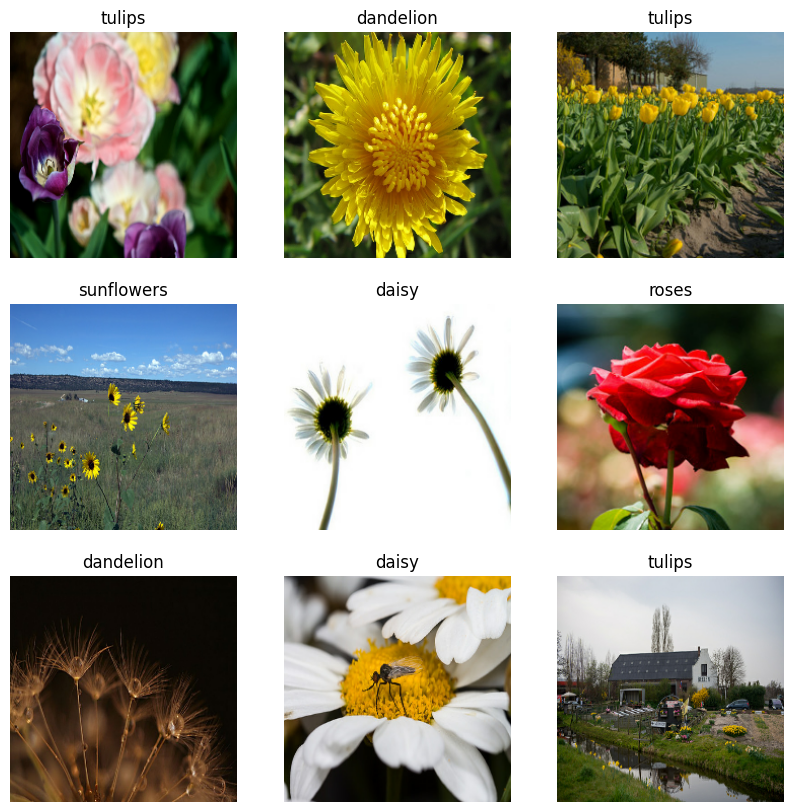

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_6 (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_3 (Rescaling)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 14s 86ms/step - accuracy: 0.7360 - loss: 0.7060 - val_accuracy: 0.8678 - val_loss: 0.4181
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 70ms/step - accuracy: 0.8287 - loss: 0.4551 - val_accuracy: 0.8665 - val_loss: 0.3863
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 69ms/step - accuracy: 0.8566 - loss: 0.3893 - val_accuracy: 0.8719 - val_loss: 0.3562
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 71ms/step - accuracy: 0.8569 - loss: 0.3848 - val_accuracy: 0.8719 - val_loss: 0.3594
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 68ms/step - accuracy: 0.8719 - loss: 0.3419 - val_accuracy: 0.8828 - val_loss: 0.3461
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 70ms/step - accuracy: 0.8818 - loss: 0.3373 - val_accuracy: 0.8951 - val_loss: 0.3288
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 67ms/step - accuracy: 0.8873 - loss: 0.3103 - val_accuracy: 0.8828 - val_loss: 0.3556
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 70ms/step - accuracy: 0.8961 - loss: 0.2777 - val_accuracy: 0.8924 - 

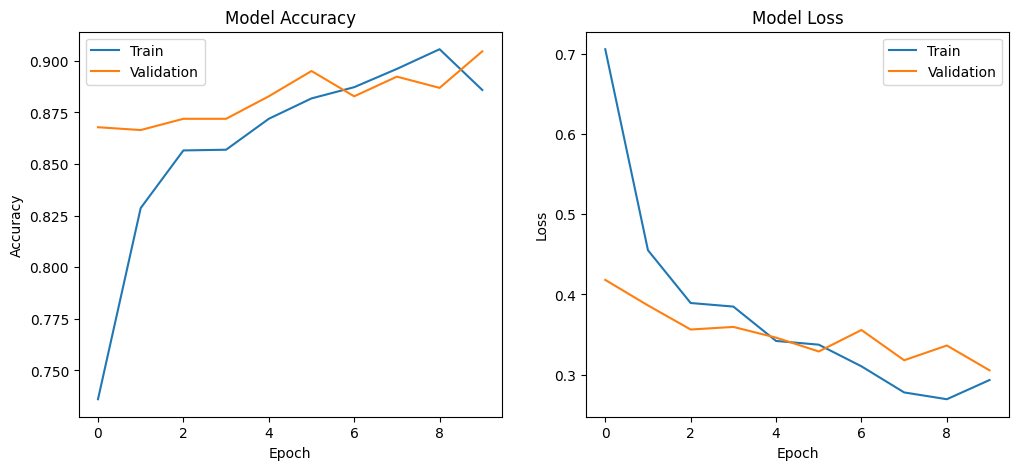

Model Saved Successfully
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Predicted Class: sunflowers
Confidence: 39.16 %


In [5]:
# =====================================================
# IMAGE CLASSIFICATION USING MOBILENETV2
# DATASET: TENSORFLOW FLOWERS
# =====================================================

# Install Libraries
# !pip install tensorflow matplotlib

import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os # Import the os module for path manipulation

print("TensorFlow Version:", tf.__version__)

# =====================================================
# LOAD DATASET
# =====================================================

dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"

data_dir = tf.keras.utils.get_file(
    "flower_photos",
    origin=dataset_url,
    untar=True
)

# Adjust data_dir to point to the actual directory containing class subfolders
data_dir = os.path.join(data_dir, 'flower_photos')

print("Dataset Location:", data_dir)

# =====================================================
# DATASET PARAMETERS
# =====================================================

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print("Classes:", class_names)

# =====================================================
# OPTIMIZE DATASET
# =====================================================

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# =====================================================
# DISPLAY SAMPLE IMAGES
# =====================================================

plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

# =====================================================
# DATA AUGMENTATION
# =====================================================

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
])

# =====================================================
# BUILD MOBILENETV2 MODEL
# =====================================================

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

model = tf.keras.Sequential([
    data_augmentation,
    tf.keras.layers.Rescaling(1./255),
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(len(class_names), activation='softmax')
])

# =====================================================
# COMPILE MODEL
# =====================================================

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# =====================================================
# TRAIN MODEL
# =====================================================

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

# =====================================================
# EVALUATE MODEL
# =====================================================

loss, accuracy = model.evaluate(val_ds)

print("Validation Accuracy:", accuracy)

# =====================================================
# PLOT ACCURACY & LOSS
# =====================================================

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train','Validation'])

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train','Validation'])

plt.show()

# =====================================================
# SAVE MODEL
# =====================================================

model.save("flower_classifier.keras")

print("Model Saved Successfully")

# =====================================================
# PREDICT NEW IMAGE
# =====================================================

img_path = "test_flower.jpg"

img = tf.keras.utils.load_img(
    img_path,
    target_size=(224,224)
)

img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)

predictions = model.predict(img_array)

score = tf.nn.softmax(predictions[0])

print(
    "Predicted Class:",
    class_names[np.argmax(score)]
)

print(
    "Confidence:",
    round(100*np.max(score),2),
    "%"
)
